# Assignment 2: Data Pre-Processing of Historical Tropical Cyclone Records
In this assignment, you will explore how to do data exploration and pre-processing with a .csv file containing a global collection of 
tropical cyclone records, the International Best Track Archive for Climate Stewardship [(IBTrACS)](https://www.ncei.noaa.gov/products/international-best-track-archive). The column variable descriptions are given [here](https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf).

The assignment has three pieces. **Part 1** sets up the private GitHub repository you will
submit every assignment to. **Part 2** applies the Week 1 machine learning vocabulary to the
Mauna Loa CO$_2$ record: one short experiment and four written questions. **Parts 3 to 7**
are the data preprocessing work on the cyclone records.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 2. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


## Part 1: Create your assignments repository

You will submit every assignment in this course by pushing to a private GitHub repository.
Set it up now.

1. Create a directory called `ml4climate2026` on your machine.
2. Add a `README.md` containing your name.
3. Initialize a git repository, and make your first commit.
4. Create a **private** repository on GitHub called `ml4climate2026`. Use exactly that name.
   Do not vary the spelling, capitalization, or punctuation.
5. Push your local repository to GitHub.
6. On GitHub, go to **Settings -> Collaborators** and add `dmw2166`.
7. Add this completed notebook to the repository, commit, and push.

Push new commits to this repository whenever you are ready to hand in an assignment.

1) Paste the output of `git log --oneline` below, showing your commit history.

In [18]:
# Run this in your ml4climate2026 repository, then paste the output here.
# Your history will differ; this is the shape it should take.
#
# $ git log --oneline
# 8f3c1a2 Add completed Assignment 1 notebook
# 1d9e4b7 Initial commit: README with my name

## Part 2: Intro to ML

The Week 1 lecture notes lay out the vocabulary: the three learning paradigms, the
eight-step workflow, and the strengths and weaknesses of data-driven methods. The questions
in this part ask you to apply those ideas to the
[Mauna Loa CO$_2$ record](https://gml.noaa.gov/ccgg/trends/), the longest continuous direct
measurement of atmospheric carbon dioxide anywhere in the world.

The cell below loads the record for you. If you did the optional coding review in
Assignment 1 you have seen it before; if not, run it and look at the columns. `average` is the
monthly mean concentration in ppm and `decimal_date` is the time of each value as a decimal
year, which is the natural x variable for fitting.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The Mauna Loa CO2 record, straight from NOAA. The file has about 40 lines of
# header comments before the data begins, which comment="#" skips.
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
co2 = pd.read_csv(url, comment="#")
co2 = co2.rename(columns={"decimal date": "decimal_date"})

# Build a proper datetime column (measurements are monthly means, dated mid-month).
co2["date"] = pd.to_datetime(dict(year=co2["year"], month=co2["month"], day=15))

# NOAA codes missing monthly means as -99.99.
co2 = co2[co2["average"] > 0].reset_index(drop=True)

co2.head()

2) Before answering anything conceptual, run one experiment.

Fit a straight line to the record using **only the data up to the end of 1999**
(`numpy.polyfit` on `decimal_date` against `average`, degree 1). Then use that line to
predict CO$_2$ for 2000 onwards. Plot the observations for the whole record together with
the extrapolated line, and report the prediction error in ppm for the most recent year in
the dataset.

fitted on 1958-1999 (502 months)
  slope = 1.323 ppm/yr   (full-record slope was 1.669)


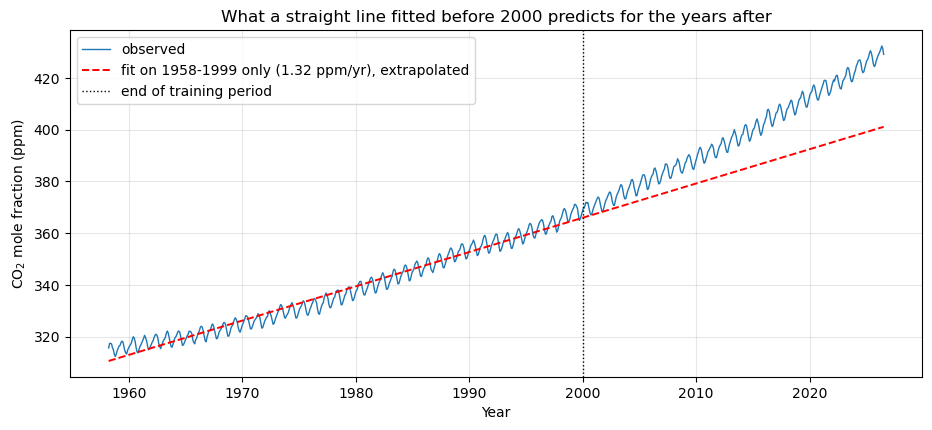


2026: observed mean 430.3 ppm, predicted 400.8 ppm
  error = +29.5 ppm  (positive means the model UNDER-predicts)

mean error over 2000-2026: +13.9 ppm


In [17]:
slope, intercept = np.polyfit(co2["decimal_date"], co2["average"], 1)   # full record, for comparison

# Fit using only the record through the end of 1999.
early = co2[co2["year"] <= 1999]
slope_e, intercept_e = np.polyfit(early["decimal_date"], early["average"], 1)
print(f"fitted on {early['year'].min()}-{early['year'].max()} "
      f"({len(early)} months)")
print(f"  slope = {slope_e:.3f} ppm/yr   (full-record slope was {slope:.3f})")

co2["extrapolated"] = slope_e * co2["decimal_date"] + intercept_e

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(co2["date"], co2["average"], lw=1, label="observed")
ax.plot(co2["date"], co2["extrapolated"], "r--", lw=1.4,
        label=f"fit on 1958-1999 only ({slope_e:.2f} ppm/yr), extrapolated")
ax.axvline(pd.Timestamp("2000-01-01"), color="k", ls=":", lw=1,
           label="end of training period")
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ mole fraction (ppm)")
ax.set_title("What a straight line fitted before 2000 predicts for the years after")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

last_year = int(co2["year"].max())
recent = co2[co2["year"] == last_year]
err = (recent["average"] - recent["extrapolated"]).mean()
print()
print(f"{last_year}: observed mean {recent['average'].mean():.1f} ppm, "
      f"predicted {recent['extrapolated'].mean():.1f} ppm")
print(f"  error = {err:+.1f} ppm  (positive means the model UNDER-predicts)")
print()
post = co2[co2["year"] >= 2000]
print(f"mean error over 2000-{last_year}: "
      f"{(post['average'] - post['extrapolated']).mean():+.1f} ppm")

# The extrapolation drifts steadily below the observations, and the gap widens every year.
# The straight line was not a bad fit to 1958-1999 -- it was a bad MODEL, because the record
# is curved and a line cannot bend. Fitting a curved process with a straight line is
# survivable while you stay inside the fitted range and becomes progressively worse the
# further outside it you go.

3) You have now fit a model that learned two parameters from data (slope and intercept) and made predictions
without anyone programming the relationship explicitly. By the definition given in the
lecture notes, is `numpy.polyfit` a machine learning algorithm? Justify your answer.

**The case *for* calling it machine learning.**

It satisfies the notes' own definition almost word for word. The notes say machine learning
methods "automatically learn from data" and "predict without being explicitly programmed to
perform a specific task". Nobody told `polyfit` that CO$_2$ rises by 1.67 ppm each year; it
determined that from the data by minimizing a loss function (squared error) and it then
produced predictions for inputs it had never seen. It has training data, learned parameters,
a loss, and an inference step. Four of the eight workflow stages in the notes map onto it
directly.

The strongest form of this argument is that **linear regression is uncontroversially a
machine learning algorithm** in every other context. It is in `scikit-learn`, it is the
first model in most ML textbooks, and it is exactly what Assignment 3 will use for a
regression task. `numpy.polyfit` and `sklearn.linear_model.LinearRegression` solve the same
optimization problem; the second is called machine learning because of the library it lives
in, which is not a property of the algorithm.

**The case *against*.**

The functional form was chosen entirely by me. The model could never have discovered that
the relationship is curved, or seasonal, or anything other than a line, I specified the
degree, and the only thing "learned" was two coefficients within a structure I imposed. On
this view machine learning is characterized by the model discovering *structure*, not just
constants, and polyfit discovers no structure at all.

There is also no generalization machinery: no held-out validation, no hyperparameters, no
guard against overfitting, and a closed-form solution rather than iterative optimization.
Nothing about it improves "with new observations" in the sense the notes describe. And
historically, least squares dates to Legendre and Gauss around 1805, calling it machine
learning makes the term cover essentially all of statistics and stop distinguishing
anything.

**Which is more convincing, and what would settle it.**

I find the case *for* more convincing, but with the concession that the question is not
really a technical one. There is no property of `polyfit` that a defender of "this is ML"
must deny; the disagreement is about where to draw a boundary on a continuum, and that
boundary is drawn by convention and by academic culture rather than by mathematics. Least
squares, ridge regression, a shallow neural network and a transformer differ in capacity and
in how they are fitted, not in kind: all minimize a loss over parameters. The honest answer
is that the notes' definition is broad enough to include polyfit, and that this is a feature
of the definition rather than a mistake in it.

The additional criterion I would propose is **whether the model's capacity is itself chosen
by confronting held-out data**. Under that criterion, `polyfit` with a degree I picked is
statistics; `polyfit` where I selected the degree by cross-validation is machine learning,
because a decision that would otherwise be mine has been delegated to the data. This is a
sharper line than "learns from data", it explains why validation is treated as central to
the discipline, and it is the reason Assignment 5 is devoted to it. It also has the honest
consequence that the same algorithm can fall on either side depending on how it was used,
which I think is correct, because the difference really is in the methodology, not the
equation.

4) The notes divide machine learning into supervised, unsupervised, and reinforcement
learning. Consider two operations on this record:

- **(a)** the straight-line fit of concentration against date (question 2)
- **(b)** extracting the mean seasonal cycle by grouping the record by calendar month and
  averaging the departure of each month from the deseasonalized trend (the optional coding
  review in Assignment 1 does this; you do not need to have done it to answer)

Which paradigm, if any, does each belong to? 

**(a) The straight-line fit is supervised learning.** Each training example is a pair (a `decimal_date` as the input feature and an `average` concentration as the label) and the
model is fitted by comparing its output against those known labels. It is a regression
problem, since the label is continuous. This is a clean fit to the definition.

Though it is worth noticing something slightly uncomfortable even here: the "label" is not an
independent annotation of the kind the notes have in mind when they describe labelling
images as cats or dogs. Nobody had to decide what the answer was; both numbers came off the
same instrument. What makes it supervised is the *structure of the task* (one variable designated as the thing to predict) not the existence of a labelling effort.

**(b) The seasonal cycle does not fit any of the three, and that is the interesting part.**

It is not supervised: there is no label being predicted and no notion of error against a
ground truth. It is not reinforcement learning: there is no agent, no action, no reward. The
tempting answer is unsupervised, since the notes describe that paradigm as identifying
"underlying patterns and correlations inherent to the data itself", and a seasonal cycle is
certainly a pattern inherent to the data.

But nothing was *learned*. `groupby("month").mean()` is an average. It has no parameters
fitted by optimization, no loss function, no capacity to be overfitted, and no ability to
generalize to anything; it simply summarizes the data it was given, and it would return the
same twelve numbers whether or not one believed there was a seasonal cycle at all. Calling
it unsupervised learning would equally make the median, the standard deviation, and drawing
a histogram into machine learning.

**What this reveals about the three-way division.** It classifies *supervision signals*, not
data analysis. The question it answers is "what kind of feedback does the algorithm get
during training?": labels, none, or a reward. That is a genuinely useful axis for
algorithms that train. It says nothing about methods that do not train, and descriptive
statistics is most of what climate science actually does. Computing a climatology, taking an
anomaly, plotting a trend, calculating an index, none of these belong in the taxonomy, and
none of them are worse for it.

So the taxonomy is a map of one region rather than a map of the whole territory, and the
practical lesson is to be suspicious of the reflex to file every analysis into one of three
boxes. The prior question is whether a model is being fitted at all. In Assignment 1, one
of the two analyses fitted a model and one summarized data, and the more useful distinction
between them is exactly that one.

5) Frame a genuine **supervised learning** problem using this dataset. You are not being asked to implement it. Your answer must
specify, concretely:

- the input features and the label 
- how you would split the data into training and test sets
- what loss function you would minimize
- what result would make you conclude the model had learned something real, as opposed to
  something you already knew


**The problem: predict next month's CO$_2$ concentration from the recent past.**

**Features and label.** The label is the concentration in month $t$. The features are the
twelve preceding monthly values, $t-1$ through $t-12$, plus the calendar month encoded as a
pair of sinusoids, $\sin(2\pi m/12)$ and $\cos(2\pi m/12)$.

The naive choice the question warns about is using **date as the only feature**. That is
what question 2 did, and it makes the problem degenerate: with one monotonically increasing
input there is nothing to learn beyond a trend line, and every prediction outside the
training period is pure extrapolation. The opposite failure is including a feature already
containing the answer: the `deseasonalized` column, for instance, is a smoothed version of
`average` computed by NOAA from the very value being predicted, so a model given it would
score almost perfectly and have learned nothing. Both are ways of making the task either
trivial or impossible, and the useful framing sits between them: give the model the recent
history and require it to project one step forward.

**The split, and why the obvious one is wrong.** The obvious split is random, shuffle the
months, hold out 20%. It is badly wrong here for two compounding reasons. First, consecutive
months are nearly identical, so a random split leaves the model with the months either side
of almost every test month and reduces the task to interpolation. Second, and more seriously,
this feature set makes the target of one row an explicit *feature* of the neighbouring rows:
month $t$ appears as a lagged feature for months $t+1$ through $t+12$. Under a random split
the answer is sitting in the training set, not merely approximated by it.

The correct split is **chronological**: train on 1958 through roughly 2010, validate on the
next several years, test on the most recent block. That is also the only split matching how
such a model would be used, fitted on the record so far and run forward.

**Loss.** Mean squared error on the concentration. Squared error is the right default for a
continuous target with roughly symmetric, well-behaved errors, and this series has no heavy
tail to worry about. I would report **RMSE in ppm** rather than the raw loss, because ppm is
interpretable and can be compared against the roughly 0.1–0.3 ppm measurement uncertainty of
the instrument itself.

**What would count as having learned something real.** Not beating the mean; that bar is
meaninglessly low for a series with a strong trend. The model must beat two much harder
baselines:

2. **Persistence**: next month equals this month. On a smooth series this is already good.
3. **Seasonal-naive plus trend**: this month last year, plus the average annual increase.
   This encodes everything already known about the record (that it rises steadily and repeats annually) and is genuinely hard to beat.

Beating persistence alone would show only that the model noticed the seasonal cycle. Beating
the second baseline would mean it had extracted something beyond "steady rise plus repeating
annual wiggle", most plausibly interannual variability such as the enhanced growth rate
during strong El Niño years. That would be a real, if modest, finding. If the model matched
but did not beat that baseline, the honest report is that the record contains little
predictable structure beyond trend and season, which is itself a useful scientific
statement, and a more likely outcome than beating it.

**A limitation worth stating up front.** Any model trained on this dataset learns the
behaviour of one station on a Pacific volcano. Mauna Loa was sited precisely because it
samples well-mixed background air, so it is unrepresentative of continental sites with local
sources by design. A model fitted here would not transfer to an urban monitoring station,
and its apparent skill would say nothing about performance there.

6) The notes state that machine learning models "typically do a poor job of extrapolating
to unseen data regimes." Your experiment in question 2 is a small demonstration of exactly
that.

Suppose you needed a projection of atmospheric CO$_2$ for the year 2100. Would a flexible
machine learning model (a neural network, say) trained on this same record do better or
worse than your straight line? Explain your reasoning, and then explain what a
physics-based carbon cycle model has access to that neither of them does.

**Worse (probably much worse) and the reason a neural network fails here is the same
reason it succeeds elsewhere.**

A neural network's advantage is flexibility: it can represent essentially any shape without
being told the functional form. Inside the range of the training data that is exactly what
you want. Outside it, it becomes the liability, because flexibility means the model has no
commitment to any particular behaviour once it leaves the region where data constrained it.
A network fitted to 1958–2026 would reproduce that period beautifully (trend, seasonal cycle, the interannual wiggles) and its output for 2100 would be governed by whatever its
activation functions happen to do far from any training point. With ReLU units that is a
linear ramp whose slope is an artefact of the final layer's weights; with saturating units it
flattens to a constant. Neither is a statement about carbon. Worse, the model's flexibility
means small changes in fitting (a different random seed, a few more epochs) would give
noticeably different 2100 values, while all fitting the historical record equally well. A
projection that depends on the random seed is not a projection.

The straight line does better only in the weak sense that it fails predictably. It encodes
one global assumption (a constant rate of increase) which is at least a claim about the
world that can be checked and rejected. Question 16 rejects it: fitted before 2000 it
under-predicts thereafter, because the true growth rate has roughly tripled over the record.
So the line is *also* wrong for 2100, and wrong in a known direction. Being wrong
transparently is a genuine advantage over being wrong arbitrarily, but it is not skill.

**What a physics-based carbon cycle model has that neither has.**

The decisive difference is not sophistication, it is **what the models take as input**.
Atmospheric CO$_2$ in 2100 is not a function of atmospheric CO$_2$ in the past. It is
mostly a function of **how much carbon humans emit between now and then**, and that quantity
appears nowhere in this dataset. It depends on energy policy, technology and economics,
things no amount of curve-fitting on the historical record can anticipate. This is why
climate projections are always reported *per emissions scenario*: the scenario is an input,
not a prediction. A statistical model extrapolating the Mauna Loa curve is implicitly
assuming the last seventy years of emissions growth continues unchanged, and it cannot
represent any alternative because it has no place to put one.

Beyond that, a carbon cycle model carries structure that constrains it where data does not:

- **Mass conservation.** Carbon is tracked between atmosphere, ocean and land. The model
  cannot produce atmospheric growth that fails to balance, whereas a fitted curve is under
  no such obligation.
- **Process representation of the sinks.** Roughly half of emitted CO$_2$ is currently
  absorbed by ocean and land. That fraction is not constant: ocean uptake slows as surface
  water acidifies and warms, and the land sink responds to CO$_2$ fertilization, temperature
  and drought. These are *feedbacks*, and they may weaken this century. A model without them
  cannot represent the most important nonlinearity in the problem.
- **The ability to be wrong in a diagnosable way.** When a physics model errs you can ask
  which process is misrepresented. When an extrapolated fit errs there is nothing to
  interrogate.

The general lesson, and the one the notes are pointing at: machine learning interpolates
within the regime it has seen. Climate projection is an extrapolation problem *by
definition*: the whole question is about a state of the system that has not occurred yet.
That is why ML has been transformative for weather prediction and emulation, which operate
inside the observed regime, while long-range projection remains the domain of process-based
models. The productive uses of ML in this space are hybrid: emulating an expensive physics
model to explore scenarios quickly, or replacing an individual parameterization inside one,
where the physics supplies the constraints and the ML supplies the speed.

## The cyclone records

The rest of the assignment uses a different dataset. Run the cells below to load and aggregate it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load and aggregate the data set
Using the following code, load in the data set (this takes a few seconds to run):

In [2]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})

This data set includes cyclone tracks (so it has multiple entries per named cyclone). We'll use the code below to create an aggregated data set for only the named cyclones, which has one entry per cyclone. You will use the data set `dfnamed` for the rest of the assignment.

In [3]:
dfnamed = df.groupby("NAME").agg(MAX_WIND=('WMO_WIND','max'),
                               MIN_PRES=('WMO_PRES','min'),
                               MEAN_LAT=('LAT','mean'),
                               MEAN_LON=('LON','mean'),
                               BASIN=('BASIN','first'),
                               SUBBASIN=('SUBBASIN','first'),
                               NATURE=('NATURE','first'),
                               SEASON=('SEASON','first')).reset_index()
dfnamed.head()

# these lines of code remove the initial dataframe (we won't need it anymore)
import gc
del df
gc.collect()

20

## Part 3: Data Exploration

How many named cyclones are there?

In [4]:
len(dfnamed)

1908

7) Use the `pandas` `hist` method to plot the marginal distributions of the variables in the dataframe `dfnamed`

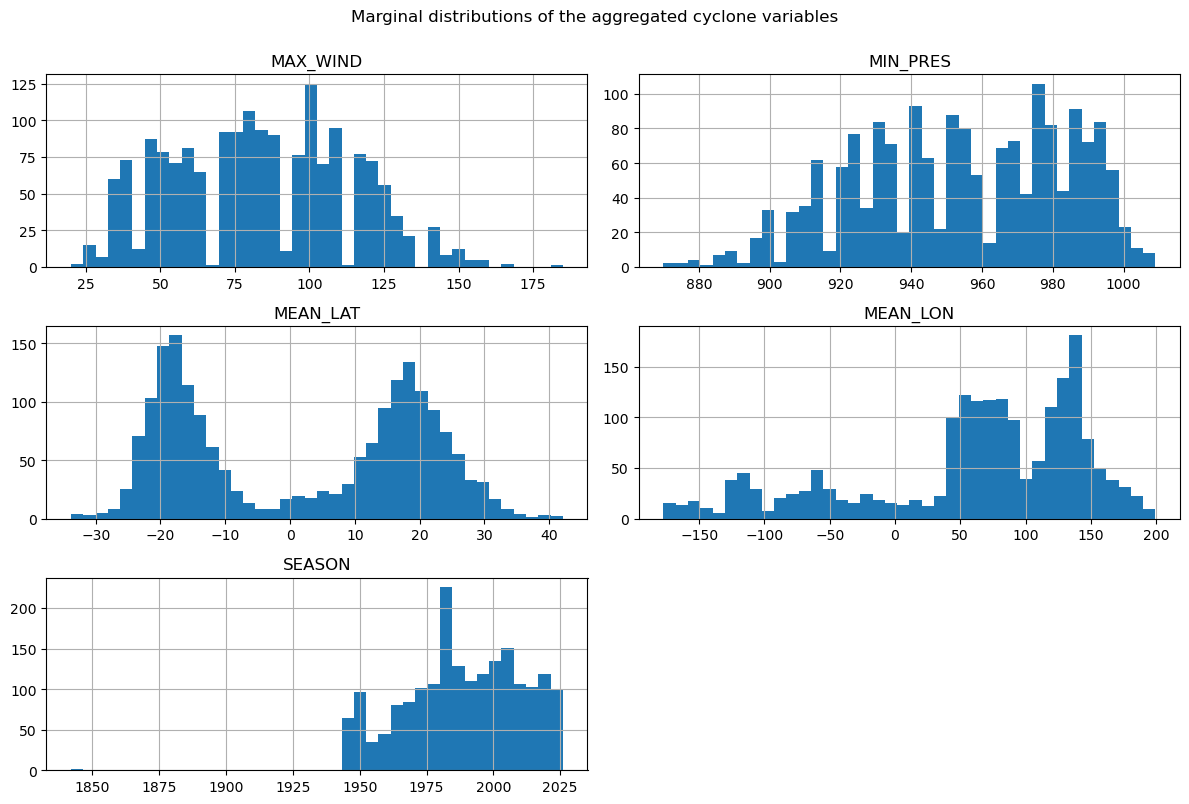

In [5]:
dfnamed.hist(figsize=(12, 8), bins=40)
plt.suptitle("Marginal distributions of the aggregated cyclone variables", y=1.0)
plt.tight_layout()
plt.show()

# Points worth noticing before modelling anything:
#  - MAX_WIND is right-skewed: many weak storms, a long thin tail of intense ones.
#  - MIN_PRES is left-skewed, the mirror image, as it must be given the physics.
#  - MEAN_LAT is strongly BIMODAL, one lobe per hemisphere. A single mean latitude
#    is close to meaningless for this variable, and any model treating latitude as
#    linear will be misled by it.
#  - SEASON is heavily weighted towards recent decades: satellite coverage means
#    modern storms are far more completely catalogued.

8) Use the `seaborn` Pairgrid function to create a scatterplot of all of the variables

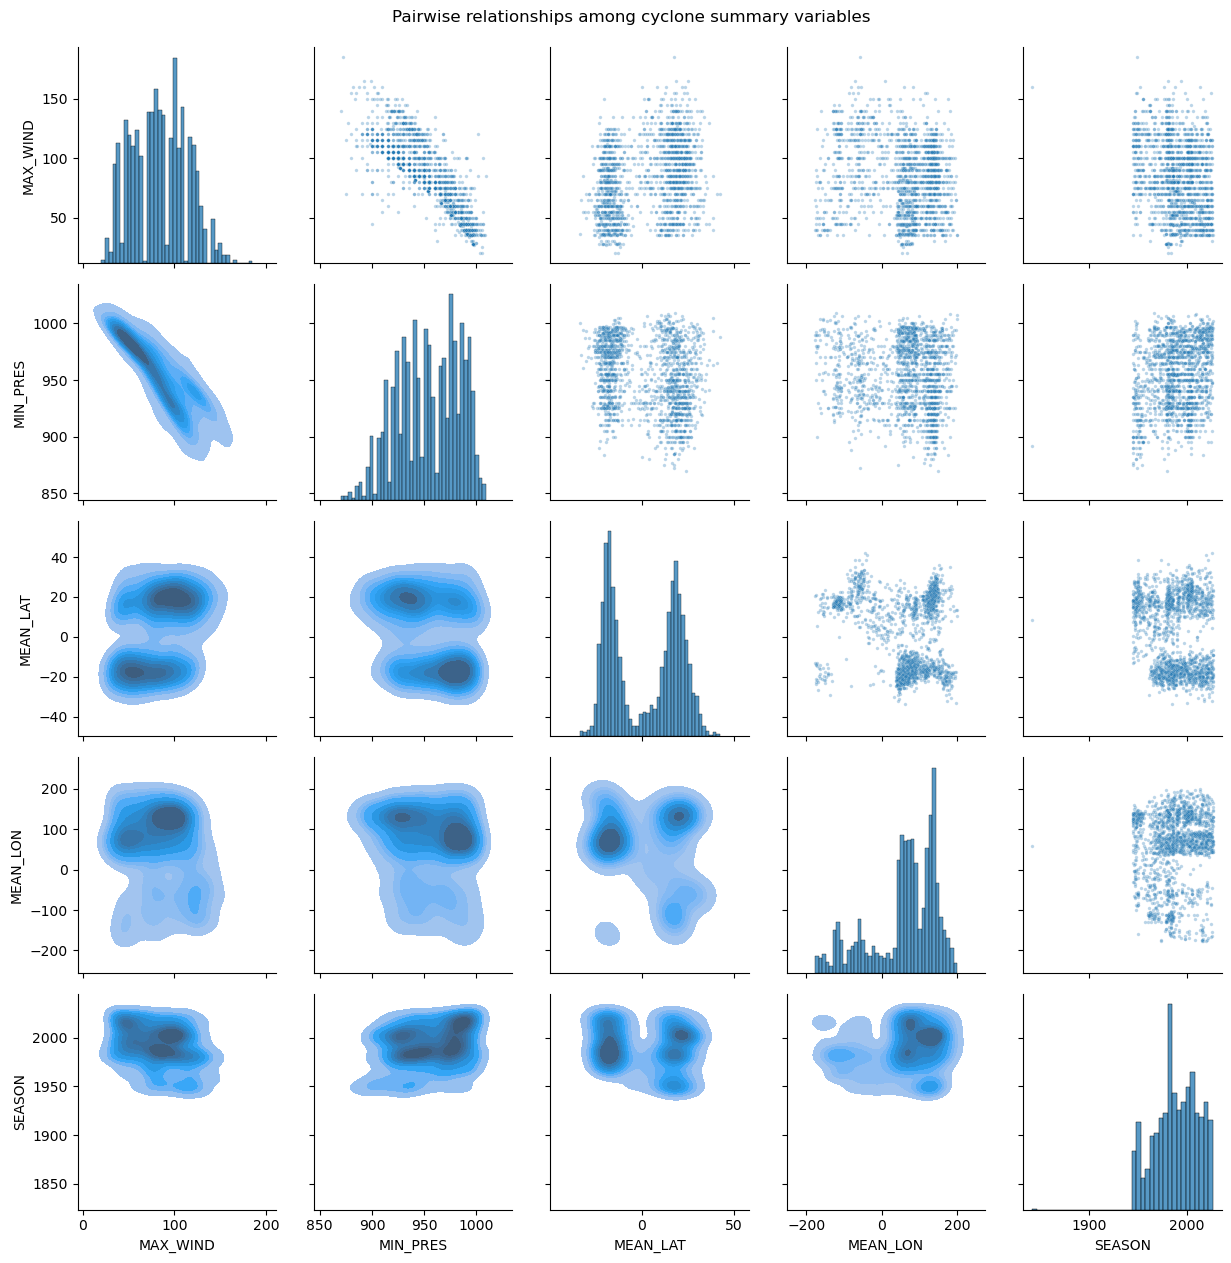

In [6]:
g = sns.PairGrid(dfnamed.drop(columns=["NAME"]), diag_sharey=False)
g.map_upper(sns.scatterplot, s=6, alpha=0.3)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, bins=40)
g.figure.suptitle("Pairwise relationships among cyclone summary variables", y=1.01)
plt.show()

# The dominant feature is the tight, nearly deterministic negative relationship
# between MIN_PRES and MAX_WIND -- the wind-pressure relationship, which is the
# single most useful thing in this dataset. Everything else is weak by comparison.
# The two lobes of MEAN_LAT show up in every panel involving latitude.

9) Using `matplotlib`, create a scatter plot of the minimum pressure vs. the maximum wind speed and color by the year the cyclone took place.

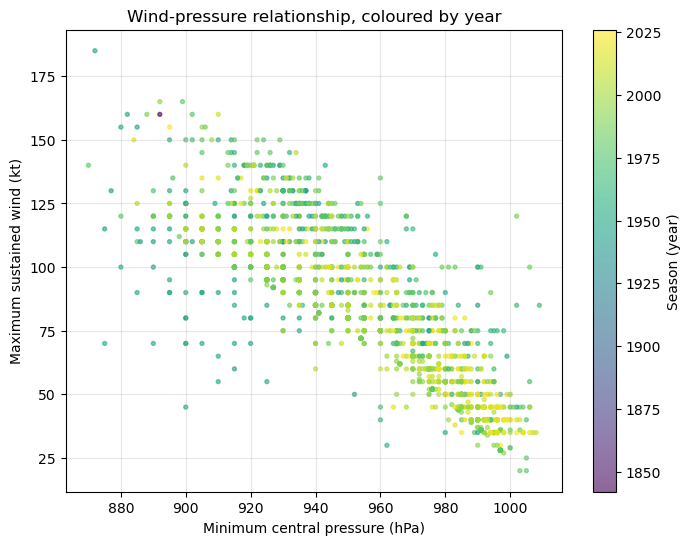

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(dfnamed["MIN_PRES"], dfnamed["MAX_WIND"],
                c=dfnamed["SEASON"], cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Season (year)")
ax.set_xlabel("Minimum central pressure (hPa)")
ax.set_ylabel("Maximum sustained wind (kt)")
ax.set_title("Wind-pressure relationship, coloured by year")
ax.grid(alpha=0.3)
plt.show()

# The relationship is tight and negative: deeper low pressure means stronger winds,
# because the pressure gradient between the storm centre and its surroundings is
# what drives the wind. Colouring by year exposes something a model would
# otherwise absorb silently -- the older (dark) points sit in a noticeably
# different, sparser band from the modern (bright) ones. Reporting practices and
# instrumentation have changed over the record, so "year" is partly a proxy for
# how the measurement was made rather than for anything physical.

## Part 4: Handle missing data
10) How many non-null values does each variable have?

In [8]:
print(dfnamed.notna().sum())
print(f"\ntotal rows: {len(dfnamed)}")
print("\nmissing per column:")
print(dfnamed.isna().sum().sort_values(ascending=False))

NAME        1908
MAX_WIND    1724
MIN_PRES    1736
MEAN_LAT    1908
MEAN_LON    1908
BASIN       1908
SUBBASIN    1908
NATURE      1908
SEASON      1908
dtype: int64

total rows: 1908

missing per column:
MAX_WIND    184
MIN_PRES    172
NAME          0
MEAN_LAT      0
MEAN_LON      0
BASIN         0
SUBBASIN      0
NATURE        0
SEASON        0
dtype: int64


11) Create a new dataframe called `dfdrop` where you have discarded the rows with NaN values in `dfnamed`

In [9]:
dfdrop = dfnamed.dropna().reset_index(drop=True)

print(f"dfnamed: {len(dfnamed)} rows")
print(f"dfdrop:  {len(dfdrop)} rows  "
      f"({100 * (1 - len(dfdrop) / len(dfnamed)):.1f}% discarded)")
dfdrop.head()

dfnamed: 1908 rows
dfdrop:  1687 rows  (11.6% discarded)


,NAME,MAX_WIND,MIN_PRES,MEAN_LAT,MEAN_LON,BASIN,SUBBASIN,NATURE,SEASON
0,ABAIMBA,43.0,995.0,-4.637234,63.031915,SI,MM,TS,2003
1,ABBY,120.0,895.0,20.905938,74.640937,NA,NA,TS,1960
2,ABE,85.0,945.0,22.272561,128.743293,WP,MM,NR,1990
3,ABEL:BETH,60.0,975.0,15.482927,131.466667,WP,MM,NR,1996
4,ABELA,50.0,987.0,-10.850769,65.370769,SI,MM,DS,2017


12. Create a new dataframe called `dfimputed` where you have imputed the missing values in `dfnamed` with 0.0.

In [10]:
dfimputed = dfnamed.fillna(0.0)

print(f"dfimputed: {len(dfimputed)} rows, NaNs remaining: {dfimputed.isna().sum().sum()}")

# Worth pausing on what this does to the data. A cyclone with no recorded pressure
# now has MIN_PRES = 0 hPa -- physically impossible, and roughly 900 hPa away from
# any real value. Imputing with zero does not fill in a plausible value; it invents
# an extreme outlier and hands it to the model as fact. Compare the summary
# statistics before and after:
print("\nMIN_PRES before imputation:")
print(dfnamed["MIN_PRES"].describe()[["mean", "std", "min"]])
print("\nMIN_PRES after imputing 0.0:")
print(dfimputed["MIN_PRES"].describe()[["mean", "std", "min"]])

# The mean drops and the standard deviation inflates, both purely as artefacts.
# Zero-imputation is a reasonable default only where zero is a meaningful value
# (a count of events, a rainfall total). For a physical measurement with a narrow
# natural range it is one of the worst choices available; the median, or a model-
# based imputation, would at least stay inside the plausible range.

dfimputed: 1908 rows, NaNs remaining: 0

MIN_PRES before imputation:
mean    954.179724
std      29.515804
min     870.000000
Name: MIN_PRES, dtype: float64

MIN_PRES after imputing 0.0:
mean    868.163522
std     274.786999
min       0.000000
Name: MIN_PRES, dtype: float64


## Part 5: Feature scaling

13. Scale the `MAX_WIND` column of your `dfdrop` dataframe using the StandardScaler and put it into an array called `y`, since it's the target we want to predict 

*Hint*: the `StandardScaler` expects a 2-D input, so reshape your column with `.values.reshape(-1, 1)` before scaling.

In [11]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()
y = target_scaler.fit_transform(dfdrop["MAX_WIND"].values.reshape(-1, 1))

print("y shape:", y.shape)
print(f"original MAX_WIND: mean {dfdrop['MAX_WIND'].mean():.2f} kt, "
      f"sd {dfdrop['MAX_WIND'].std():.2f} kt")
print(f"scaled y:          mean {y.mean():.2e}, sd {y.std():.4f}")

# The scaler is kept in a variable because the inverse transform is needed later
# to turn model predictions back into knots. Discarding it is a common and
# annoying mistake.

y shape: (1687, 1)
original MAX_WIND: mean 84.23 kt, sd 29.76 kt
scaled y:          mean 3.16e-17, sd 1.0000


14. Create a copy of your `dfdrop` dataframe called `dffeatures`, and drop the `NAME` and `MAX_WIND` columns from your `dffeatures` dataframe, since the `MAX_WIND` variable is going to be your target variable and we won't need the cyclone names any longer

In [12]:
dffeatures = dfdrop.copy()
dffeatures = dffeatures.drop(columns=["NAME", "MAX_WIND"])

print("columns retained:", list(dffeatures.columns))
dffeatures.head()

# NAME is dropped because it is an identifier, not a feature -- it carries no
# information that generalizes to a storm the model has not seen. MAX_WIND is
# dropped because it is the target: leaving it in the feature matrix would let the
# model read off the answer, the most basic form of leakage there is.

columns retained: ['MIN_PRES', 'MEAN_LAT', 'MEAN_LON', 'BASIN', 'SUBBASIN', 'NATURE', 'SEASON']


,MIN_PRES,MEAN_LAT,MEAN_LON,BASIN,SUBBASIN,NATURE,SEASON
0,995.0,-4.637234,63.031915,SI,MM,TS,2003
1,895.0,20.905938,74.640937,NA,NA,TS,1960
2,945.0,22.272561,128.743293,WP,MM,NR,1990
3,975.0,15.482927,131.466667,WP,MM,NR,1996
4,987.0,-10.850769,65.370769,SI,MM,DS,2017


## Part 6: Encode Categorical Variables
15) Check which unique categories each of the variables `BASIN`, `SUBBASIN`, and `NATURE` take, using the `dffeatures` dataframe.

In [13]:
for col in ["BASIN", "SUBBASIN", "NATURE"]:
    vals = dffeatures[col].unique()
    print(f"{col}: {len(vals)} categories -> {sorted(map(str, vals))}")

BASIN: 6 categories -> ['EP', 'NA', 'NI', 'SI', 'SP', 'WP']
SUBBASIN: 9 categories -> ['AS', 'BB', 'CP', 'CS', 'EA', 'GM', 'MM', 'NA', 'WA']
NATURE: 6 categories -> ['DS', 'ET', 'MX', 'NR', 'SS', 'TS']


16. Print out the number of cyclones in each basin and subbasin. Also print out how many of each storm type there is.

In [14]:
for col in ["BASIN", "SUBBASIN", "NATURE"]:
    print(f"--- {col} ---")
    print(dffeatures[col].value_counts())
    print()

# Both BASIN and SUBBASIN are very unevenly populated, and several categories hold
# only a handful of storms. One-hot encoding these produces columns that are almost
# entirely zero, which contribute little and can destabilize a linear model.

--- BASIN ---
BASIN
SI    550
WP    464
SP    246
EP    175
NA    174
NI     78
Name: count, dtype: int64

--- SUBBASIN ---
SUBBASIN
MM    1115
WA     199
NA     113
EA      88
BB      52
CS      36
CP      33
AS      26
GM      25
Name: count, dtype: int64

--- NATURE ---
NATURE
TS    1125
DS     305
NR     155
MX      79
SS      16
ET       7
Name: count, dtype: int64



17. Encode the `BASIN`, `SUBBASIN`, and `NATURE` variables in `dffeatures` using One Hot Encoding, and standardize `MIN_PRES`, `MEAN_LAT`, and `MEAN_LON`, and `SEASON` using the `StandardScaler`.

*Hint*: you can do this in one step using the `sci-kit learn` `ColumnTransformer`. Create an array called `X` that contains the encoded categorical variables and the scaled numerical variables.

In [15]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical = ["BASIN", "SUBBASIN", "NATURE"]
numerical = ["MIN_PRES", "MEAN_LAT", "MEAN_LON", "SEASON"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ("num", StandardScaler(), numerical),
])

X = preprocess.fit_transform(dffeatures)

print("X shape:", X.shape)
print(f"  {len(preprocess.named_transformers_['cat'].get_feature_names_out())} one-hot columns")
print(f"  {len(numerical)} standardized numerical columns")
print("\nfirst row:", np.round(X[0], 3))

X shape: (1687, 25)
  21 one-hot columns
  4 standardized numerical columns

first row: [ 0.     0.     0.     1.     0.     0.     0.     0.     0.     0.
  0.     0.     1.     0.     0.     0.     0.     0.     0.     0.
  1.     1.41  -0.381  0.028  0.578]


18. Print out the feature names associated with the columns in your `X` array.

In [16]:
feature_names = preprocess.get_feature_names_out()
print(f"{len(feature_names)} features:\n")
for i, name in enumerate(feature_names):
    print(f"  {i:2d}  {name}")

# Keeping the names alongside X is what makes a fitted model interpretable later:
# without them, a coefficient or feature importance is just an index.

25 features:

   0  cat__BASIN_EP
   1  cat__BASIN_NA
   2  cat__BASIN_NI
   3  cat__BASIN_SI
   4  cat__BASIN_SP
   5  cat__BASIN_WP
   6  cat__SUBBASIN_AS
   7  cat__SUBBASIN_BB
   8  cat__SUBBASIN_CP
   9  cat__SUBBASIN_CS
  10  cat__SUBBASIN_EA
  11  cat__SUBBASIN_GM
  12  cat__SUBBASIN_MM
  13  cat__SUBBASIN_NA
  14  cat__SUBBASIN_WA
  15  cat__NATURE_DS
  16  cat__NATURE_ET
  17  cat__NATURE_MX
  18  cat__NATURE_NR
  19  cat__NATURE_SS
  20  cat__NATURE_TS
  21  num__MIN_PRES
  22  num__MEAN_LAT
  23  num__MEAN_LON
  24  num__SEASON


## Part 7: Train, Validation, & Test Split

19. Split your data set into a training and test/validation data set using the `train_test_split` function with 80% of your original data for training and 20% for the testing and validation data sets.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test_val, y_train, y_test_val = train_test_split(
    X, y, test_size=0.2, random_state=0)

print("X_train:   ", X_train.shape)
print("X_test_val:", X_test_val.shape)

X_train:    (1349, 25)
X_test_val: (338, 25)


20. Split your `X_test_val` and `y_test_val` again into separate validation and test data sets, that are 10% each of the original data set. Double check that the size of your final training, validation, and test data sets are correct by printing out the shape of each array.

In [18]:
# The held-out 20% is halved, giving 10% of the original data to each of the
# validation and test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.5, random_state=0)

n = len(X)
print(f"{'set':<12} {'X shape':>14} {'y shape':>12} {'% of total':>11}")
print("-" * 52)
for name, Xs, ys in [("train", X_train, y_train),
                     ("validation", X_val, y_val),
                     ("test", X_test, y_test)]:
    print(f"{name:<12} {str(Xs.shape):>14} {str(ys.shape):>12} "
          f"{100 * len(Xs) / n:>10.1f}%")
print("-" * 52)
print(f"{'total':<12} {len(X_train) + len(X_val) + len(X_test):>14} "
      f"{'':>12} {100.0:>10.1f}%")

set                 X shape      y shape  % of total
----------------------------------------------------
train            (1349, 25)    (1349, 1)       80.0%
validation        (169, 25)     (169, 1)       10.0%
test              (169, 25)     (169, 1)       10.0%
----------------------------------------------------
total                  1687                   100.0%


21. Save the Training, validation, and test data sets and labels as numpy arrays using np.save()

In [19]:
for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
                  ("y_train", y_train), ("y_val", y_val), ("y_test", y_test)]:
    np.save(f"{name}.npy", arr)
    print(f"saved {name}.npy  {arr.shape}")

# Saving the SPLIT arrays rather than re-splitting each session is what makes the
# rest of the course reproducible: every later assignment that uses this data sees
# exactly the same training set, so results are comparable across notebooks.

saved X_train.npy  (1349, 25)
saved X_val.npy  (169, 25)
saved X_test.npy  (169, 25)
saved y_train.npy  (1349, 1)
saved y_val.npy  (169, 1)
saved y_test.npy  (169, 1)
